## Objetivo de Negócio

## Objetivo do Modelo

# Data Understanding

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score 

## Análise Inicial do Dados

In [50]:
df.shape #Verificar o formato do nosso dataset

(1000000, 8)

## Estatísticas descritivas

In [52]:
df.describe() #Gerar estatísticas descritivas para as nossas colunas

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


Podemos observar, que o dataset possui 1 milhão de observações e 8 colunas e todas as colunas tem o mesmo tipo de dados ``float64``. Mas observando o comportamento de ``repeat_retailer`` ,``used_chip``, ``used_pin_number``, ``online_order`` e ``fraud`` no dataset, podemos perceber que se tratam de colunas categóricas, então uma padronização que podemos fazer na etapa de Data Preparation, é a conversão dessas colunas para o tipo inteiro, para melhor separação dessas classes e por consumir menos espaço de memória.

In [55]:
df.isnull().sum() #verificação da existência de valores ausentes no dataset

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Com esses dois testes, observamos que não temos valores ausentes e nem duplicados. Para um terceiro teste, vamos verrificar se os valores dos dados númericos fazem sentido. Vamos verificar se não temos valores que saiam do padrão esperados para eles. No caso das colunas númericas, não podemmos ter valores negativos para distâncias e compras, e para as colunas categóricas, não podemos ter valores diferentes de 0 e 1. O metódo ``.describe()`` já nós dá essa dica, mas para fins de confirmação, vamos fazer uma lógica simples para confirmar.

O metódo ``.describe()`` nos mostra, também, a média e mediana de cada coluna do nosso dataset, mas caso nosso dataset tenha um desbalanceamento na proporção do nosso target ``fraud``, essa medida global pode acabar "engolindo" nossa informação sobre a classe minoritária. Vamos primeiro verificar o balanceamento do nosso dataset

Temos desbalanceamento moderado, então para ter um indicação precisa se temos ou não outliers, optei por dividir o dataset por ``fraud``.

Com essa divisão temos algumas informações importantes. A média em casos normais (não fraude) é maior que a mediana, por mais que isso seja um sinal de outlier em estatística, se tratando de comportamento de transações, podemos considerar que existem esses tipos de transações de forma autêntica (uma viagem, emergência, etc). Por isso é natural que a média seja puxada um pouco para cima. Já no caso de fraude, a a distância é brutalmente maior, já que podemos interpretar que o objetivo do fraudador é diferente, esvaziar o limite o mais rápido possível por exemplo. Isso confirma que a fraude não segue o padrão de consumo habitual de usuários, gerando outliers extremos que distorcem completamente a média e mediana da classe.

Nessa etapa, queremos uma análise mais minuciosa dos nossos dados, mostrando gráficos, tabelas, medidas resumo e outros métodos. Esse item será dividido em três tipos de análise: univariada, bivariada e multivarida.

Para a análise univariada de variáveis categóricas foi realizado um estudo de contagem de valores

Para as variáveis númericas foram feitas análise gráficas

Após o entendimento individual de cada variável é necessário entender a relação entre elas. Sendo assim, vamos analisar a relação de cada variável com nosso ``target``.

Com essa informação podemos perceber que compras feitas online e compras que não usam senha, tem uma grande quantidade de transações fraudulentas

No gráfico de distribuição de ``ratio_to_median_purchase_price``, podemos notar um grande ponto de atenção, que o pico de transaçãoes legitímas, fica em torno de de 1, enquanto a de transações fraudulentas é 5x maior.  

Em ``distance_from_home`` podemos ver que a mediana de transações fraudulentas é maior que a de não fraudeulentas. Mas a maior discrepancia que podemos ver é em ``ratio_to_median_purchase_price`` onde a mediana de compra fraudulentas é maior que a média de compras legitímas.

A análise muitivariada é uma extensão da análise bivarida, que vai nos permitir investigar e compreender as relações entre três ou mais variáveis.


|``repeat_retailer``|``used_chip``|``used_pin_number``|``online_order``| tipo de compra|
|-|-|-|-|--|
|0|0|0|0|Contacless|
|0|0|0|1|Online|
|0|0|1|0|Contactless + senha|
|0|0|1|1|Online + autenticação|
|0|1|0|0|Chip + assinatura|
|0|1|0|1|Token + online|
|0|1|1|0|Inserção + senha|
|0|1|1|1|Anomalia|
|1|0|0|0|Contactless|
|1|0|0|1|Online|
|1|0|1|0|Contactless + senha|
|1|0|1|1|Online + autenticação|
|1|1|0|0|Chip + assinatura|
|1|1|0|1|Token + online|
|1|1|1|0|Inserção + senha|
|1|1|1|1|Anomalia|

Por fim, vamos verificar, qual combinação de categorias tem a maior frequência de fraudes.

Podemos perceber que as 5 combinações com maior taxa de fraudes, 4 delas possuem ``online_order``. 

Para a análise muultivariada, queremos ver o comportamento da distância de cada do usuário, com sua valor e sua relação com nosso ``target``.

Esse gráfico revelou que transações que combinam distâncias mais longas e valores muito acima da mediana são quase todas fraude. Podemos observar que um comportamento legítimo se encontra mais concetrado na parte inferior do gráfico.

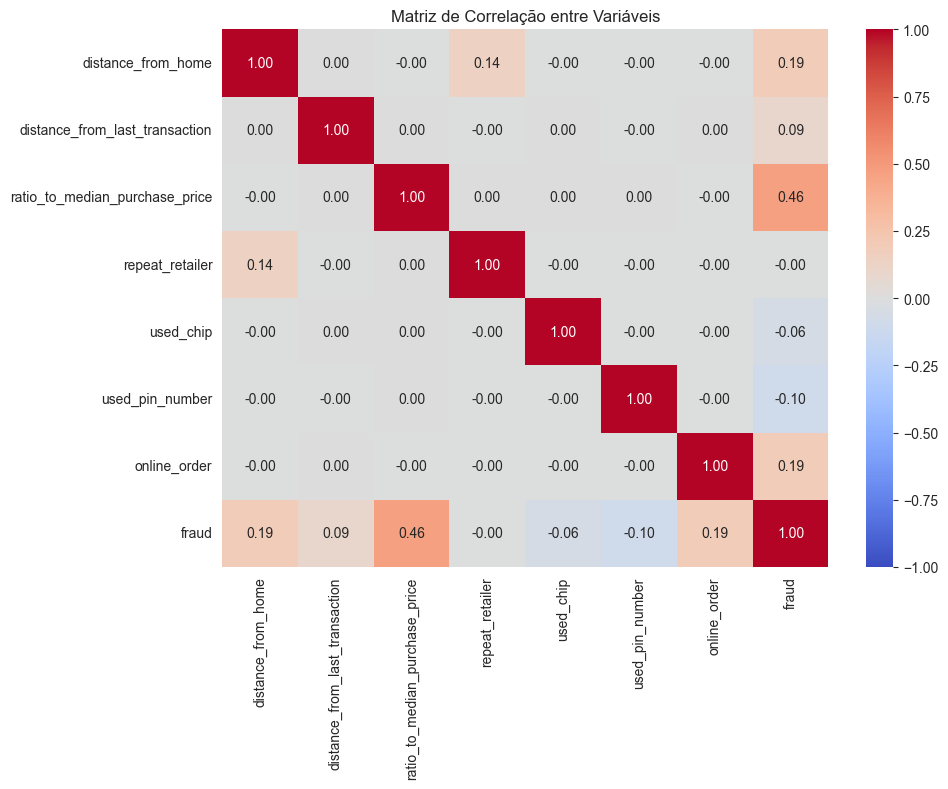

In [104]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

# Data Preparation

## Tratamento de Valores Nulos

## Codificação de variávies categóricas

In [105]:
def definir_score_risco(row):
    if (row['online_order']==1) and (row['used_pin_number']==0) and (row['used_chip']==0) and (row['repeat_retailer']==0):
        return 4 
    elif (row['used_pin_number']==0) and (row['used_chip']==0): 
        return 3 
    elif (row['used_pin_number']==1) and (row['used_chip']==1):
        return 1 
    else:
        return 2 

df['risk_score'] = df.apply(definir_score_risco, axis=1)

In [106]:
cols_para_converter = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']

for col in cols_para_converter:
    df[col] = df[col].astype(int)

Como temos um base de dados grande, optei pela divisão de 80% total da base de dados para treinamento e 20% para treinamento.

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

Como estamos lidando com valores muitos discrepantes para distâncias e valores, precisamos colocar esses valores na mesma "régua", para usá-los em algoritmos matemáticos. Optei por utilizar ``StandardScaler`` para que todos tenham o mesmo peso matemático.

In [119]:
X_train.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,risk_score
235822,-0.177922,23.169656,0.905537,1,1,0,1,2
838334,0.252198,-0.161912,-0.560024,1,0,0,1,3
326737,0.248244,0.590090,-0.539432,1,1,0,1,2
162333,-0.180717,-0.044787,-0.588932,1,0,0,0,3
795564,0.006569,-0.106491,1.296082,1,1,0,1,2


Nessa fase, o objetivo é identificar o modelo que oferece o melhor desempenho preditivo ou descritivo para o nosso problema. Para selecionar quais técnicos de modelagem utilizar, precisamos entender qual o problema está sendo discutido, e isso vimos na etapa de **Bussines Understanding**. Sendo assim, foram escolhidos 2 tipos de de modelos para serem feitos:

1. **Logistic Regression**: Cumpre o papel de ser um modelo simples, mas não foi escolhido por esperar o melhor resultado, mas para servir de base de performace para nosso modelo mais complexo, além de ser um modelo leve.
2. **Random Forest Classifier**: Escolhida pela robustez em lidar com relações que não são lineares e interações mais complexas entre variáveis. Por ser um modelo baseado em árvores assemble, ele lida melhor com outliers.

In [125]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

In [128]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluation

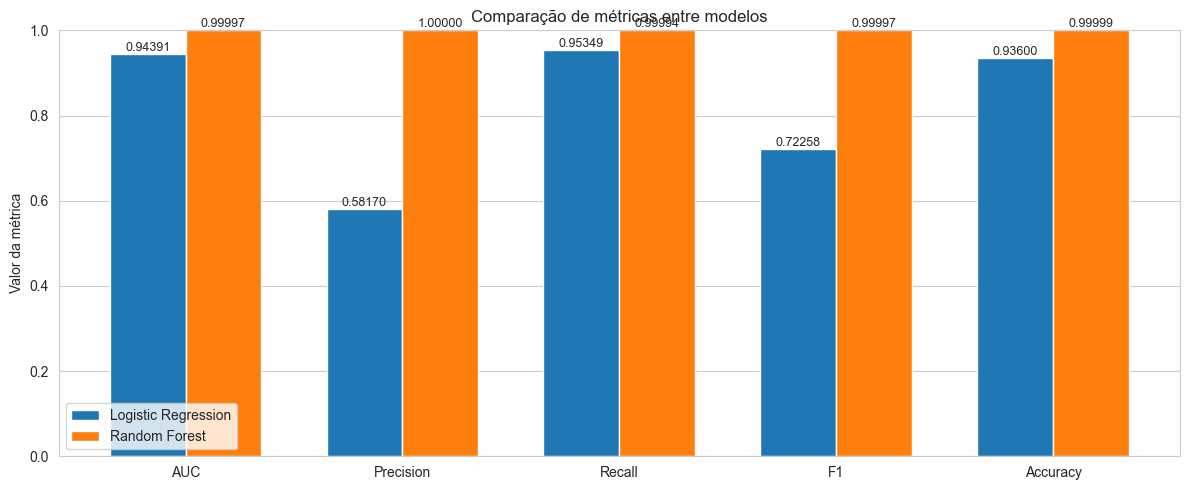

In [144]:
metricas = ['AUC', 'Precision', 'Recall', 'F1', 'Accuracy']
log_vals = [auc_log, prec_log, rec_log, f1_log, acc_log]
rf_vals = [auc_rf, prec_rf, rec_rf, f1_rf, acc_rf]
x = np.arange(len(metricas)) 
width = 0.35  
plt.figure(figsize=(12, 5))

bars1 = plt.bar(x - width/2, log_vals, width, label='Logistic Regression')
bars2 = plt.bar(x + width/2, rf_vals, width, label='Random Forest')

plt.ylabel('Valor da métrica')
plt.title('Comparação de métricas entre modelos')
plt.xticks(x, metricas)
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f'{y:.5f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

### Escolha para Produção

### Threshold

### Sentido para o ponto de vista do negócio

# Deployment

## Planejamento da Implantação

## Impacto de Negócio

## Recomendações para Implementação

## Monitorizaçaõ e Manutenção dos modelos